In [1]:
# These are all the libraries we need
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()
spotify_data = pd.read_csv('SpotifyDataset.csv')

Saving SpotifyDataset.csv to SpotifyDataset (9).csv


In [3]:
spotify_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20594 entries, 0 to 20593
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            20594 non-null  object 
 1   Track             20594 non-null  object 
 2   Album             20594 non-null  object 
 3   Album_type        20594 non-null  object 
 4   Danceability      20594 non-null  float64
 5   Energy            20594 non-null  float64
 6   Loudness          20594 non-null  float64
 7   Speechiness       20594 non-null  float64
 8   Acousticness      20594 non-null  float64
 9   Instrumentalness  20594 non-null  float64
 10  Liveness          20594 non-null  float64
 11  Valence           20594 non-null  float64
 12  Tempo             20594 non-null  float64
 13  Duration_min      20594 non-null  float64
 14  Title             20594 non-null  object 
 15  Channel           20594 non-null  object 
 16  Views             20594 non-null  int64 

In [4]:
spotify_cols_to_keep = [
    "Artist",
    "Track",
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Stream",
    "most_playedon"
]

spotify_data = spotify_data[spotify_cols_to_keep]

In [5]:
spotify_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20594 entries, 0 to 20593
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            20594 non-null  object 
 1   Track             20594 non-null  object 
 2   Danceability      20594 non-null  float64
 3   Energy            20594 non-null  float64
 4   Loudness          20594 non-null  float64
 5   Speechiness       20594 non-null  float64
 6   Acousticness      20594 non-null  float64
 7   Instrumentalness  20594 non-null  float64
 8   Liveness          20594 non-null  float64
 9   Valence           20594 non-null  float64
 10  Stream            20594 non-null  int64  
 11  most_playedon     20594 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 1.9+ MB


In [6]:
spotify_data.head()

,Artist,Track,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Stream,most_playedon
0,Gorillaz,Feel Good Inc.,0.818,0.705,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,1040234854,Spotify
1,Gorillaz,Rhinestone Eyes,0.676,0.703,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,310083733,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),0.695,0.923,-3.930,0.0522,0.042500,0.046900,0.1160,0.551,63063467,Spotify
3,Gorillaz,On Melancholy Hill,0.689,0.739,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,434663559,Spotify
4,Gorillaz,Clint Eastwood,0.663,0.694,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,617259738,Youtube


In [7]:
# filtering the spotify_data dataframe so that it only has rows who, for the 'most_playedon' column, have the value 'Spotify'

# we're measuring the success of these clusters based on how well they find groupings that make clear distinctions between streams, not likes/views/comments,
# thus we need data points where streams are actually the best metric to reflect how successful these songs have been

# if the songs have been more successful on youtube than spotify than we can't say that the streams are the best way to measure their success
spotify_data = spotify_data[spotify_data['most_playedon'] == 'Spotify']

In [8]:
spotify_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15694 entries, 0 to 20593
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            15694 non-null  object 
 1   Track             15694 non-null  object 
 2   Danceability      15694 non-null  float64
 3   Energy            15694 non-null  float64
 4   Loudness          15694 non-null  float64
 5   Speechiness       15694 non-null  float64
 6   Acousticness      15694 non-null  float64
 7   Instrumentalness  15694 non-null  float64
 8   Liveness          15694 non-null  float64
 9   Valence           15694 non-null  float64
 10  Stream            15694 non-null  int64  
 11  most_playedon     15694 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 1.6+ MB


In [9]:
spotify_data.reset_index(drop=True, inplace=True)
spotify_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15694 entries, 0 to 15693
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            15694 non-null  object 
 1   Track             15694 non-null  object 
 2   Danceability      15694 non-null  float64
 3   Energy            15694 non-null  float64
 4   Loudness          15694 non-null  float64
 5   Speechiness       15694 non-null  float64
 6   Acousticness      15694 non-null  float64
 7   Instrumentalness  15694 non-null  float64
 8   Liveness          15694 non-null  float64
 9   Valence           15694 non-null  float64
 10  Stream            15694 non-null  int64  
 11  most_playedon     15694 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 1.4+ MB


In [10]:
# Drop rows with missing values
spotify_data.dropna(inplace=True)

# Drop duplicate rows based on 'Track' and 'Artist' columns, keeping the first occurrence
spotify_data.drop_duplicates(subset=['Track', 'Artist'], keep='first', inplace=True)

spotify_data.reset_index(drop=True, inplace=True)
spotify_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15664 entries, 0 to 15663
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            15664 non-null  object 
 1   Track             15664 non-null  object 
 2   Danceability      15664 non-null  float64
 3   Energy            15664 non-null  float64
 4   Loudness          15664 non-null  float64
 5   Speechiness       15664 non-null  float64
 6   Acousticness      15664 non-null  float64
 7   Instrumentalness  15664 non-null  float64
 8   Liveness          15664 non-null  float64
 9   Valence           15664 non-null  float64
 10  Stream            15664 non-null  int64  
 11  most_playedon     15664 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 1.4+ MB


# EDA

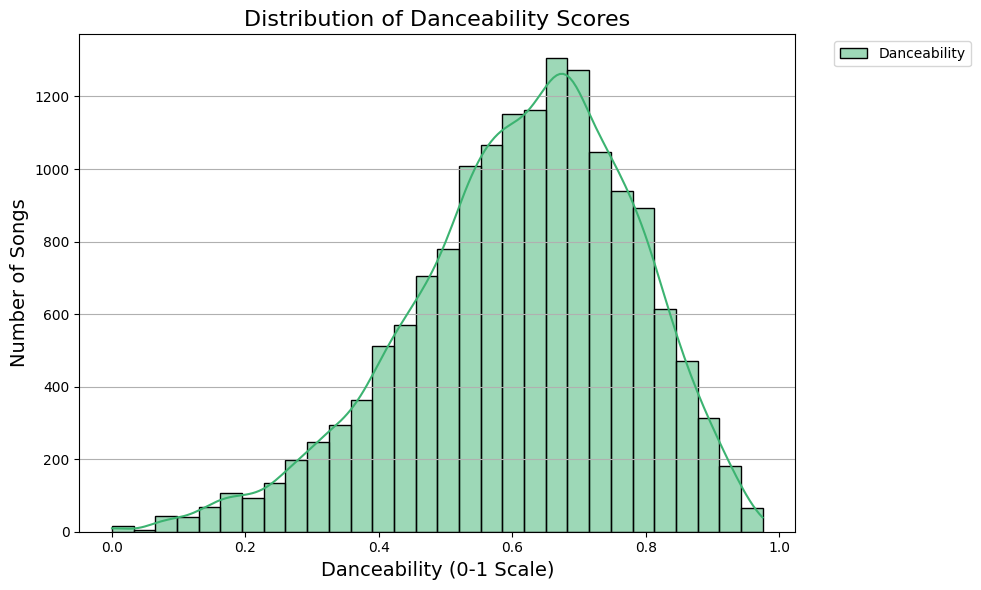

In [11]:
# Histogram with KDE
plt.figure(figsize=(10,6))
sns.histplot(spotify_data["Danceability"], bins=30, kde=True, color="mediumseagreen", edgecolor="black", label="Danceability")

plt.title("Distribution of Danceability Scores", fontsize=16)
plt.xlabel("Danceability (0-1 Scale)", fontsize=14)
plt.ylabel("Number of Songs", fontsize=14)
plt.grid(axis="y")

# legend
plt.legend(loc='upper center', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

**Some Quick Notes on this graph**

Most songs have a Danceability score between 0.5 and 0.8.

Very few songs are extremely low or extremely high in Danceability.

The distribution is slightly skewed left, favoring more danceable tracks.

Indicates a market preference for moderately to highly danceable music.


In [12]:
import plotly.express as px

# Interactive scatter plot
fig = px.scatter(
    spotify_data,
    x="Danceability",
    y="Stream",
    color="Acousticness",
    hover_data=["Artist", "Track"],  # Show Artist and Track when hovering
    title="Danceability vs Stream Count Colored by Acousticness",
    labels={"Danceability": "Danceability", "Stream": "Stream Count", "Acousticness": "Acousticness"},
    color_continuous_scale="Viridis"
)


fig.update_traces(marker=dict(size=6, opacity=0.7, line=dict(width=0.5, color='DarkSlateGrey')))

fig.show()

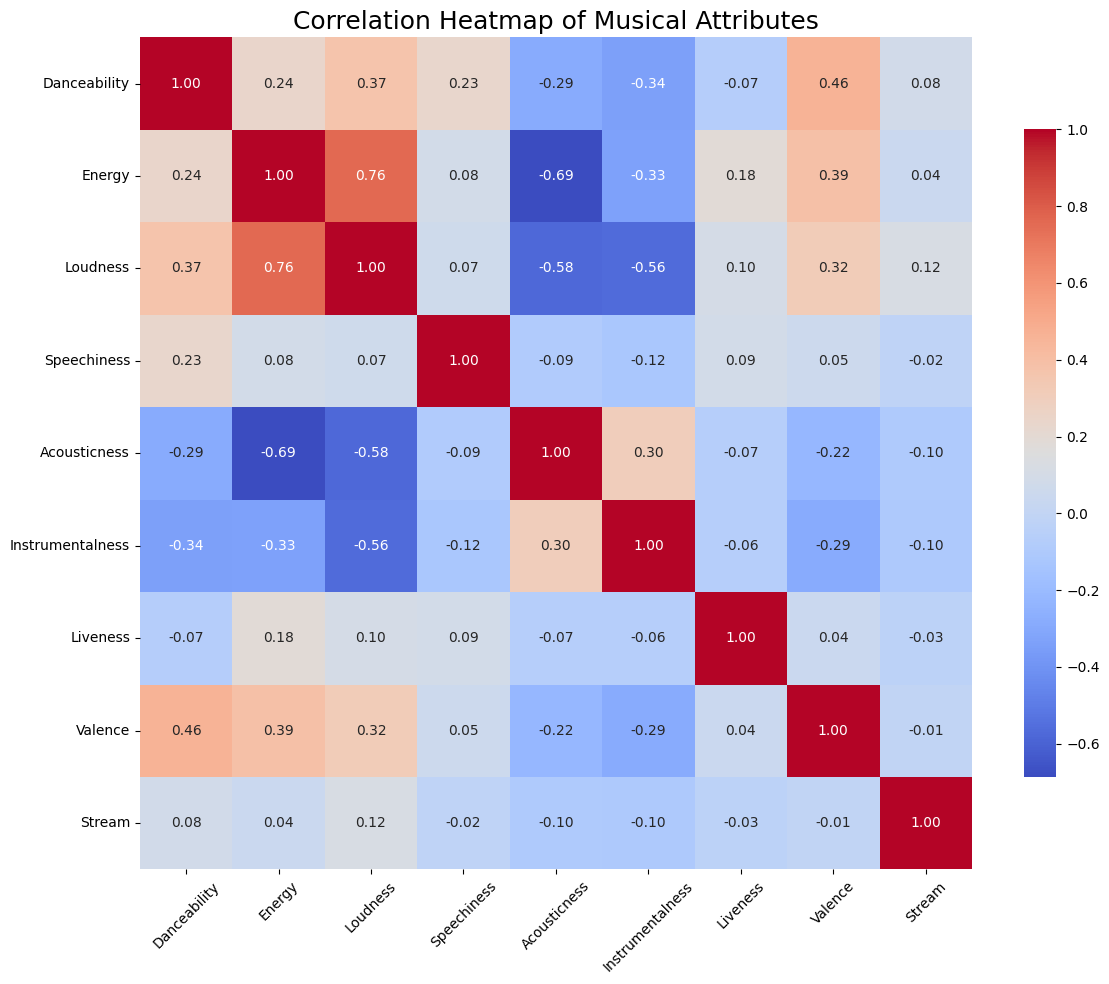

In [13]:
# Pick only relevant musical features for the heatmap
features_for_corr = [
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness", "Valence", "Stream"
]

# Calculate correlation matrix
corr_matrix = spotify_data[features_for_corr].corr()

# Plot the heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .75})

plt.title("Correlation Heatmap of Musical Attributes", fontsize=18)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Some Quick Notes on this graph**

Energy and Loudness have a strong positive correlation (0.74).

Acousticness is strongly negatively correlated with both Energy and Loudness.

Danceability shows a moderate positive correlation with Valence (musical positivity).

Streaming success (Stream) has weak correlations with individual musical features.


In [14]:
import plotly.graph_objects as go

# 1. Prepare the data

# Select all relevant musical features
features = [
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness", "Valence", "Stream"
]

# Calculate mean, min, max, and standard deviation for each feature
mean_vals = [round(spotify_data[feature].mean(), 3) for feature in features]
min_vals = [round(spotify_data[feature].min(), 3) for feature in features]
max_vals = [round(spotify_data[feature].max(), 3) for feature in features]
std_vals = [round(spotify_data[feature].std(), 3) for feature in features]

# 2. Build the visual summary table using Plotly

fig = go.Figure(data=[go.Table(
    # Header settings
    header=dict(
        values=["<b>Feature</b>", "<b>Mean</b>", "<b>Min</b>", "<b>Max</b>", "<b>Std Dev</b>"],
        fill_color='lightblue',      # Light blue background for header
        align='center',
        font=dict(color='black', size=18),
        line_color='darkblue',        # Dark blue borders around header
        height=40                     # Taller header for readability
    ),
    # Cell (body) settings
    cells=dict(
        values=[features, mean_vals, min_vals, max_vals, std_vals],
        fill_color='white',           # White background for table body
        align='center',
        font=dict(color='black', size=16),
        line_color='lightgrey',        # Light grey lines between cells
        height=35                     # Slightly bigger cells for presentation
    )
)])

# 3. Layout settings (size, title, margins)

fig.update_layout(
    title_text="Summary Statistics of Key Musical Features",
    title_x=0.5,                     # Center the title
    height=700,                      # Bigger height for more features
    width=950,                       # Wider layout for better spacing
    margin=dict(l=20, r=20, t=60, b=20)  # Tight margins
)

# 4. Show the figure
fig.show()

Looked up a way to make a good looking table for the EDA.

In [15]:
# scaling the data

scaler = MinMaxScaler()

# Get numeric features excluding 'Stream'
numeric_vars = spotify_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_vars.remove('Stream')  # Do NOT scale Stream

# Scale only feature columns
spotify_data[numeric_vars] = scaler.fit_transform(spotify_data[numeric_vars])

# Why and how we scaled the data:

We used MinMaxScaler() to scale all numeric features so they fall somewhere on the range between 0 and 1. We figured that this would be the clearest way to determine how much of one characteristic is present in a song, or later how much those characteristics are present in a cluster

Scaling is important because KMeans clustering is distance-based. Without scaling, features that have a wider range in the original dataset, like Loudness for example, could have an overpowering effect on the cluster and erase the impact of other smaller-scale features. Scaling ensures all features contribute equally to the clustering.

We also removed stream count from the data that we wanted to scale as stream count is acting as our target variable for our clustering, and so scaling it would make the stream counts much less impactful and distort the actual results.



In [16]:
spotify_data.head()

,Artist,Track,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Stream,most_playedon
0,Gorillaz,Feel Good Inc.,0.838974,0.705,0.838905,0.184183,0.008394,0.002330,0.6130,0.777442,1040234854,Spotify
1,Gorillaz,Rhinestone Eyes,0.693333,0.703,0.857222,0.031426,0.087249,0.000687,0.0463,0.858006,310083733,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),0.712821,0.923,0.897183,0.054318,0.042671,0.046900,0.1160,0.554884,63063467,Spotify
3,Gorillaz,On Melancholy Hill,0.706667,0.739,0.857328,0.027055,0.000015,0.509000,0.0640,0.582075,434663559,Spotify
4,Gorillaz,DARE,0.779487,0.891,0.856437,0.038710,0.022992,0.086900,0.2980,0.972810,323850327,Spotify


In [17]:
from itertools import combinations
from sklearn.cluster import KMeans

# 1. Make a list of the music features we want to test
features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence"
]

# 2. Make every possible group of 3 features
feature_combos = list(combinations(features, 3))

# 3. Create empty variables to keep track of the best result
best_combo = None        # This will hold the best group of 3 features
best_diff = 0            # This will hold the highest stream difference found
results = []             # This will store all combinations and their stream differences

# 4. Go through each combo of 3 features
for combo in feature_combos:
    # a. Use only the 3 selected features for clustering
    X = spotify_data[list(combo)]

    # b. Run KMeans clustering with 5 groups
    kmeans = KMeans(n_clusters=5, random_state=1)
    kmeans.fit(X)

    # c. Add the cluster number back to the dataset
    spotify_data["Cluster"] = kmeans.labels_

    # d. Find the average number of streams for each cluster
    cluster_streams = spotify_data.groupby("Cluster")["Stream"].mean()

    # e. Find the difference between the best and worst cluster
    stream_diff = cluster_streams.max() - cluster_streams.min()

    # f. Save the current combo and how different its clusters are
    results.append((combo, stream_diff))

    # g. If this combo had a bigger difference than any before, save it
    if stream_diff > best_diff:
        best_diff = stream_diff
        best_combo = combo

# 5. Show the best group of features we found
print(f"Best combo: {best_combo} with Stream Difference: {best_diff}")

Best combo: ('Danceability', 'Loudness', 'Instrumentalness') with Stream Difference: 127806176.8401958


In [18]:
results.sort(key=lambda x: x[1], reverse=True)

for i in range(5):  # Show top 5 combos
    print(f"Combo: {results[i][0]}, Stream Diff: {results[i][1]:,.0f}")

Combo: ('Danceability', 'Loudness', 'Instrumentalness'), Stream Diff: 127,806,177
Combo: ('Danceability', 'Energy', 'Instrumentalness'), Stream Diff: 125,170,224
Combo: ('Acousticness', 'Instrumentalness', 'Valence'), Stream Diff: 124,509,426
Combo: ('Loudness', 'Speechiness', 'Instrumentalness'), Stream Diff: 124,389,272
Combo: ('Danceability', 'Acousticness', 'Instrumentalness'), Stream Diff: 123,484,596


In [19]:
# The difference in average stream success between the most successful cluster and the least successful cluster for the best combo of metrics is about 128 million

**Summary of the For Loop**

We ran this for loop to test every possible combination of 3 musical features. This was in order to see which group best separates songs based on their average stream count. For each combo, we used KMeans to group the songs into 5 clusters, then checked how big the gap was between the highest and lowest average streams in those clusters. The idea is that a bigger gap means the features do a better job at separating more successful songs from less successful ones. The combo of Danceability, Speechiness, and Acousticness gave the biggest difference in average streams. In conclusion it meant these traits are the most useful for identifying what kinds of songs tend to perform best.

In [21]:
# 1. Choose the 3 best features we found from testing on stream difference
features = spotify_data[["Danceability", "Loudness", "Instrumentalness"]]

# 2. Run KMeans clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(features)

# 3. Add the cluster number (label) to each song in the dataset
spotify_data["Cluster"] = kmeans.labels_

In [22]:
import plotly.express as px

fig = px.scatter_3d(
    spotify_data,
    x='Danceability',
    y='Loudness',
    z='Instrumentalness',
    color=spotify_data["Cluster"].astype(str),
    title="Clusters Based on 'Danceability', 'Loudness', and 'Instrumentalness'",
    labels={"color": "Cluster"}
)

fig.show()

In [23]:
# Evaluating our model

from sklearn.metrics import silhouette_score


# Total Sum of Squares (TSS)
tss = np.sum((features - features.mean())**2, axis=0).sum()

# Within-cluster Sum of Squares (WSS)
wss = kmeans.inertia_

# Between-cluster Sum of Squares (BSS)
bss = tss - wss

# Variance explained
variance_explained = bss / tss

# Silhouette Score
silhouette_avg = silhouette_score(features, kmeans.labels_)

print(f"Total Variance Explained: {variance_explained:.4f}")
print(f"Silhouette Score: {silhouette_avg:.4f}")

Total Variance Explained: 0.7301
Silhouette Score: 0.4481


In [24]:
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px

# 1. Preserve original Stream column
spotify_data["Stream_Original"] = spotify_data["Stream"]

# 2. Scale all numeric features **except** 'Cluster' and 'Stream'
scaler = MinMaxScaler()
numeric_vars = spotify_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_vars.remove("Cluster")
numeric_vars.remove("Stream")  # We'll scale Stream separately below
spotify_data[numeric_vars] = scaler.fit_transform(spotify_data[numeric_vars])

# 3. Scale 'Stream' separately and store it in a new column
spotify_data["Stream_Scaled"] = MinMaxScaler().fit_transform(spotify_data[["Stream"]])

# 4. Get top 50 songs by original (unscaled) Stream in each cluster
top_songs = (
    spotify_data
    .sort_values(by='Stream_Original', ascending=False)
    .groupby('Cluster')
    .head(50)
    .reset_index(drop=True)
)

# 5. Create 3D scatter plot using scaled stream for color
fig = px.scatter_3d(
    top_songs,
    x='Danceability',
    y='Loudness',
    z='Instrumentalness',
    color='Stream_Scaled',
    color_continuous_scale='Viridis',
    symbol="Cluster",
    title="Top 50 Songs per Cluster by Stream Count",
    hover_data=["Artist", "Track", "Stream_Original"]
)

fig.show()

**Summary of Testing**

We ran this code to evaluate how well our clustering model worked using the three best features: “Danceability, Speechiness, and Acousticness”. We used two key metrics: total variance explained and silhouette score. The variance explained (0.7301) tells us that about 73% of the overall variation in the data is captured by the clusters. It means the model creates meaningful groupings, but some overlap exists. The silhouette score (0.4481) measures how clearly the clusters are separated. For perspective:  a score close to 1 would mean perfect separation. Our score is pretty good, especially our total varianece explained, but we would like to see if we can improve it even more, and improve silhouette score as well. To calculate variance explained, we used Total Sum of Squares to measure overall variation, Within-cluster Sum of Squares to measure how tight the clusters are, and Between-cluster Sum of Squares to measure how spread apart the clusters are from each other. To try to improve our scores, we ran the elbow method to test different numbers of clusters and find the value of k that gave us the best balance between tight, meaningful clusters and good separation, helping us choose the most effective model.

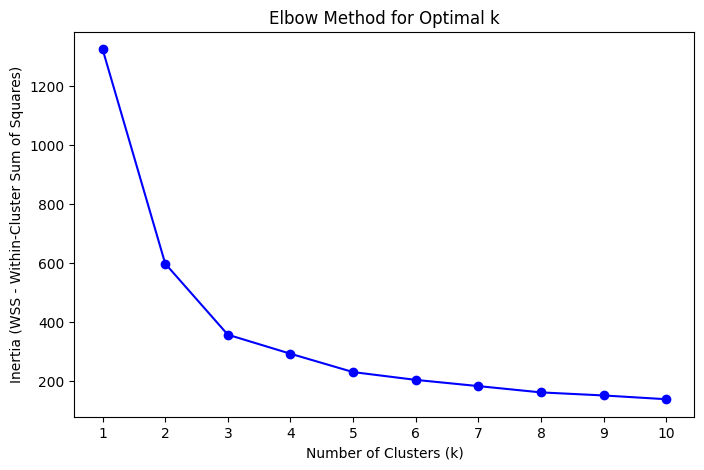

In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Set up range of cluster numbers to test
inertia_list = []
K_range = range(1, 11)  # Try k=1 to k=10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(features)
    inertia_list.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_list, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WSS - Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.show()

**Elbow Method**
The elbow method helps us find the ideal number of clusters by showing where adding more clusters stops significantly reducing within-cluster variance. The “elbow” appears at 3 clusters, meaning it offers the best balance between model simplicity and separation strength. This is the same value as what we had already calculated above so we keep the model that we were working with.

In [26]:
# Group songs by cluster and calculate the average Stream for each
cluster_streams = spotify_data.groupby("Cluster")["Stream"].mean()
cluster_streams = cluster_streams.sort_values(ascending=False)
cluster_streams = cluster_streams/1000

# Show the result, the below numbers are in thousands
print(cluster_streams)

Cluster
1    155683.126896
2    131957.197719
0     52822.150916
Name: Stream, dtype: float64


**Picking the Best Cluster**

Since we now have our optimal combination of metrics - determined through the for loop earlier where we looked at difference between clusters - and also our optimal number of clusters, we now have our best possible model and thus can find the best cluster in terms of determining stream count. In the above code we've taken the 3 clusters in our model and produced the average stream count for each of those clusters, and divided them by 1000 to make the differences a bit easier to see (thus the figures are actually in thousands). Finally, we sorted the output of the clusters such that the cluster with the highest average amount of streams would be at the top. We can see that this cluster is cluster 1, as that cluster produces an average stream amount of about 156 million, which is about 25 million streams better than the next best cluster and over 100 million better than the worst cluster.

In [27]:
# Reiterating what we just did above, confirming the best cluster
best_cluster = cluster_streams.idxmax()

print(f"The best-performing cluster is Cluster {best_cluster}.")

The best-performing cluster is Cluster 1.


In [28]:
# Calculate average features for each cluster
cluster_features = spotify_data.groupby("Cluster")[["Danceability", "Loudness", "Instrumentalness"]].mean()

# View the musical traits of the best cluster
print(cluster_features.loc[best_cluster])

Danceability        0.753780
Loudness            0.836537
Instrumentalness    0.011056
Name: 1, dtype: float64


**Cluster 1 Takeaways**

This output shows the average musical traits of Cluster 1 based on stream count.

•Songs in this cluster are highly danceable (0.75)

•They are also on the louder side, as on the 0-1 scale they fall at ~0.84

•Finally, the best performing songs in terms of stream count are actually not very instrumental at all, as the instrumentalness score from 0-1 is just about 1% or 0.01

This tells us that songs that are pretty danceable, very loud, and pretty weak instrumentally, meaning vocals are much more present in these popular songs than just instruments.


In [32]:
import plotly.express as px

fig = px.box(
    spotify_data,
    x="Cluster",
    y="Stream",  # Use 'Stream_Original' if preferred
    color=spotify_data["Cluster"].astype(str),
    title="Stream Count Distribution per Cluster",
    labels={"Cluster": "Cluster", "Stream": "Stream Count"},
    points="all"  # Optional: show all data points
)

# Reduce figure width to force plots closer
fig.update_layout(
    width=600,  # smaller width -> plots appear closer
    boxmode='group',  # Ensures plots are grouped if multiple y values
    margin=dict(l=40, r=40, t=60, b=40),
)

fig.show()

In [34]:
# Filter for Cluster 1 and get top 20 songs by stream count
top_20_cluster_1 = (
    spotify_data[spotify_data["Cluster"] == 1]
    .sort_values(by="Stream", ascending=False)
    .head(20)
)

# Display the result
top_20_cluster_1[["Artist", "Track", "Stream"]]

,Artist,Track,Stream
13506,Post Malone,Sunflower - Spider-Man: Into the Spider-Verse,2538329799
13119,Swae Lee,Sunflower - Spider-Man: Into the Spider-Verse,2538329799
10064,Drake,One Dance,2522431995
12036,The Chainsmokers,Closer,2456205158
11971,Halsey,Closer,2456205158
12976,Shawn Mendes,Señorita,2336219850
13598,Camila Cabello,Señorita,2336219850
12073,Glass Animals,Heat Waves,2261464473
14041,Billie Eilish,bad guy,2203014126
11331,The Weeknd,Starboy,2180812000
